In [2]:
!pip install nltk wordcloud seaborn

In [33]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/vivi/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

 **Step 1 — Import libraries & load dataset**

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud
import re

# Display settings
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.grid'] = True

df = pd.read_csv("appstore_instagram_reviews_anonymized.csv")

df.head()

,appId,country,date,id,score,text,title,url,userName,userUrl,version
0,389801252,DE,2024-03-20T22:37:03-07:00,11067766035,1,"When I want to share any stories, posts or ree...",List of friends in weird order,https://itunes.apple.com/de/review?id=38980125...,988858b9f96ee718616ad5dc2496ff911ff86bd790caad...,https://itunes.apple.com/de/reviews/id159880897,323.0.0
1,389801252,DE,2024-03-20T22:17:05-07:00,11067726970,4,I have been using the app for a week now. I ca...,Great companion,https://itunes.apple.com/de/review?id=38980125...,06dfad50909f5bc85a0a4198d91da9e5d5ae9954e8bba6...,https://itunes.apple.com/de/reviews/id1333052389,323.0.0
2,389801252,DE,2024-03-20T16:08:40-07:00,11066866484,1,"Instagram, was ist nur mit euch los? Es ist fr...",#Instagram #Fehler #Verbesserung dringend nötig,https://itunes.apple.com/de/review?id=38980125...,4b8d13b92ce712f53651cb538b1c079daa782136547a20...,https://itunes.apple.com/de/reviews/id711608090,323.0.0
3,389801252,DE,2024-03-20T15:54:39-07:00,11066832683,1,Die neue Schriftart ist so unglaublich hässlich.,Hässliche Layout,https://itunes.apple.com/de/review?id=38980125...,52acf5c35b9fa5653f8fb7b9ab7ec305e0ead4f07708bc...,https://itunes.apple.com/de/reviews/id830638504,323.0.0
4,389801252,DE,2024-03-20T14:59:23-07:00,11066699753,1,Null zufrieden darum gelöscht,Instagram absoluter Müll geworden sorry aber e...,https://itunes.apple.com/de/review?id=38980125...,f31334bd164a58cffae342f04040b0f7cb2ad9416ed0b0...,https://itunes.apple.com/de/reviews/id1193916555,323.0.0


**Step 2 — Clean data**

In [35]:
# Keep only required columns
df = df[['country', 'date', 'score', 'text', 'title', 'version']].copy()

# Convert date format
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date'])

# Convert score to numeric
df['score'] = pd.to_numeric(df['score'], errors='coerce')
df = df.dropna(subset=['score'])

# Merge title + text
df['title'] = df['title'].fillna('')
df['text'] = df['text'].fillna('')
df['review_full'] = (df['title'] + " " + df['text']).str.strip()
df = df[df['review_full'] != ""]

# Create time variables
df['year'] = df['date'].dt.year
df['year_month'] = df['date'].dt.to_period('M').astype(str)

df.head()

/var/folders/1t/pp3bc6656j15vp1hn_w6mcph0000gn/T/ipykernel_33799/3432835300.py:20: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['year_month'] = df['date'].dt.to_period('M').astype(str)


,country,date,score,text,title,version,review_full,year,year_month
0,DE,2024-03-20 22:37:03-07:00,1,"When I want to share any stories, posts or ree...",List of friends in weird order,323.0.0,List of friends in weird order When I want to ...,2024,2024-03
1,DE,2024-03-20 22:17:05-07:00,4,I have been using the app for a week now. I ca...,Great companion,323.0.0,Great companion I have been using the app for ...,2024,2024-03
2,DE,2024-03-20 16:08:40-07:00,1,"Instagram, was ist nur mit euch los? Es ist fr...",#Instagram #Fehler #Verbesserung dringend nötig,323.0.0,#Instagram #Fehler #Verbesserung dringend nöti...,2024,2024-03
3,DE,2024-03-20 15:54:39-07:00,1,Die neue Schriftart ist so unglaublich hässlich.,Hässliche Layout,323.0.0,Hässliche Layout Die neue Schriftart ist so un...,2024,2024-03
4,DE,2024-03-20 14:59:23-07:00,1,Null zufrieden darum gelöscht,Instagram absoluter Müll geworden sorry aber e...,323.0.0,Instagram absoluter Müll geworden sorry aber e...,2024,2024-03


**Step 3 — Sentiment Analysis**  
Sentiment analysis is a natural language processing (NLP) method that identifies whether a piece of text expresses a positive, negative, or neutral attitude.
In this project, we apply sentiment analysis to Instagram’s App Store reviews to evaluate users’ emotional reactions to the app over time.

We use this method because star ratings alone do not fully reflect users’ true feelings. A user might give a low rating but write a positive comment, or give a high rating while expressing frustration in the text. By analyzing the written review itself, sentiment analysis helps us capture the actual tone and meaning behind each review.

This allows us to more accurately understand how users’ opinions of Instagram have changed across different years, app versions, and countries. It also helps identify patterns in what users like or dislike, providing deeper insights that ratings alone cannot show.

**This sentence can be placed on the slide**
：Sentiment analysis helps us identify whether each review is positive, negative, or neutral, allowing us to understand users’ true feelings beyond star ratings.

In [36]:
# Initialize VADER
sia = SentimentIntensityAnalyzer()

# Compute sentiment score
df['sentiment_score'] = df['review_full'].apply(
    lambda x: sia.polarity_scores(str(x))['compound']
)

# Convert score → label (positive/neutral/negative)
def label_sentiment(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df['sentiment_label'] = df['sentiment_score'].apply(label_sentiment)

df[['review_full', 'score', 'sentiment_score', 'sentiment_label']].head()

,review_full,score,sentiment_score,sentiment_label
0,List of friends in weird order When I want to ...,1,0.8550,positive
1,Great companion I have been using the app for ...,4,0.9349,positive
2,#Instagram #Fehler #Verbesserung dringend nöti...,1,0.0000,neutral
3,Hässliche Layout Die neue Schriftart ist so un...,1,-0.5994,negative
4,Instagram absoluter Müll geworden sorry aber e...,1,-0.6682,negative


**Step 4 — Rating & Sentiment Distribution**

In [37]:
print(df['score'].value_counts().sort_index())
print(df['sentiment_label'].value_counts())

score
1    264
2     54
3     56
4     33
5     93
Name: count, dtype: int64
sentiment_label
negative    196
positive    185
neutral     119
Name: count, dtype: int64


The distribution of star ratings shows that the majority of reviews are clustered at the lowest rating level, with 264 users giving Instagram a 1-star review, far exceeding all other categories. Higher ratings (4 and 5 stars) are noticeably fewer, suggesting that a significant portion of users expressed dissatisfaction with the app.  

Sentiment analysis further supports this trend. Although the number of positive and negative reviews is relatively close (196 negative vs. 185 positive), negative sentiment still appears slightly more dominant. Meanwhile, 119 reviews are classified as neutral, indicating a mix of informational or emotionally balanced comments.  

Together, these results suggest that while some users still express positive feelings toward Instagram, overall user feedback skews more negative, with both the rating distribution and sentiment classification highlighting a generally critical attitude among users.

/var/folders/1t/pp3bc6656j15vp1hn_w6mcph0000gn/T/ipykernel_33799/3199988280.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


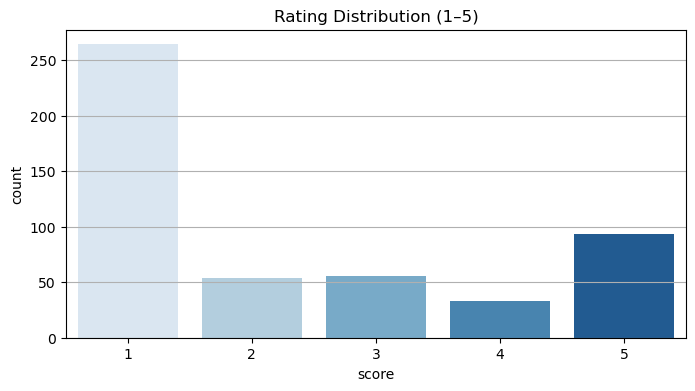

/var/folders/1t/pp3bc6656j15vp1hn_w6mcph0000gn/T/ipykernel_33799/3199988280.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


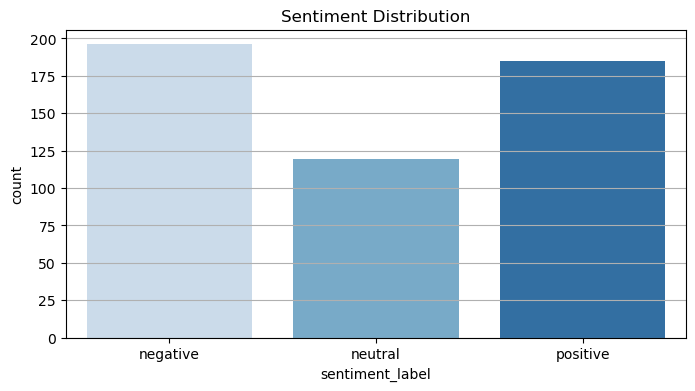

In [38]:
# Rating distribution
import seaborn as sns
import matplotlib.pyplot as plt
colors = sns.color_palette("Blues", n_colors=5)

sns.countplot(
    data=df,
    x='score',
    palette=colors
)
plt.title("Rating Distribution (1–5)")
plt.show()

# Sentiment distribution
colors_sent = sns.color_palette("Blues", n_colors=3)
sns.countplot(
    data=df,
    x='sentiment_label',
    order=['negative', 'neutral', 'positive'],
    palette=colors_sent
)
plt.title("Sentiment Distribution")
plt.show()

**Step 5 — Rating vs Sentiment (crosstab + heatmap)**

sentiment_label  negative  neutral  positive
score                                       
1                     137       61        66
2                      22       17        15
3                      24       10        22
4                       3       16        14
5                      10       15        68


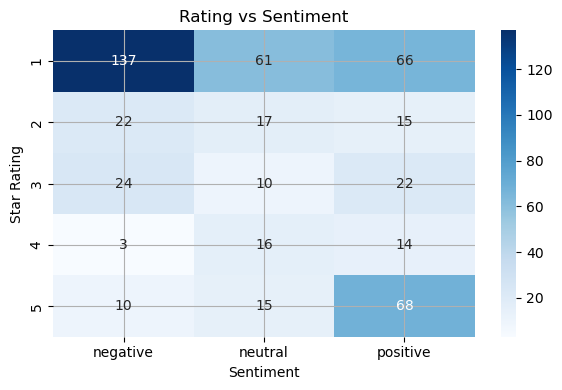

In [39]:
# Create crosstab between star rating and sentiment label
rating_sent_table = pd.crosstab(df['score'], df['sentiment_label'])

print(rating_sent_table)

# Plot heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(
    rating_sent_table,
    annot=True, fmt='d',
    cmap="Blues"
)
plt.title("Rating vs Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Star Rating")
plt.tight_layout()
plt.show()

The heatmap shows that while low ratings are strongly associated with negative sentiment, many reviews show mismatched patterns, indicating that star ratings alone do not fully capture users’ true feelings.

**Step 6 — Country-level analysis**

In [40]:
# Aggregate average rating, average sentiment and review count by country
country_stats = (
    df.groupby('country')
      .agg(
          avg_score=('score', 'mean'),
          avg_sentiment=('sentiment_score', 'mean'),
          review_count=('review_full', 'size')
      )
      .reset_index()
      .sort_values('avg_sentiment')
)

country_stats

,country,avg_score,avg_sentiment,review_count
1,DE,1.81,-0.237684,100
2,GB,2.27,-0.008721,100
0,CA,2.18,0.000460,100
3,IN,2.60,0.108436,100
4,US,2.51,0.111787,100


6.1 Average sentiment by country

/var/folders/1t/pp3bc6656j15vp1hn_w6mcph0000gn/T/ipykernel_33799/1119160468.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


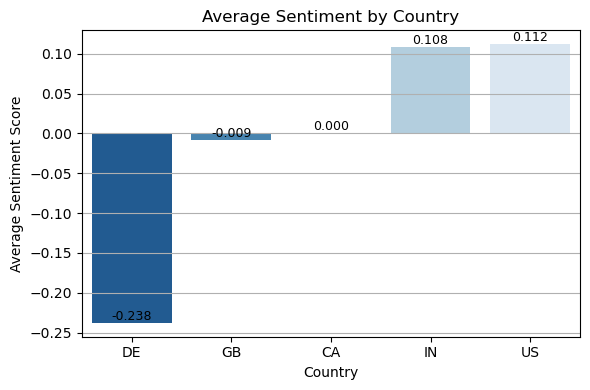

In [46]:
plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=country_stats,
    x='country', y='avg_sentiment',
    palette="Blues_r"  
)

plt.title("Average Sentiment by Country")
plt.xlabel("Country")
plt.ylabel("Average Sentiment Score")

# Add labels
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.3f}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom', fontsize=9
    )

plt.tight_layout()
plt.show()

6.2 Average rating by country

/var/folders/1t/pp3bc6656j15vp1hn_w6mcph0000gn/T/ipykernel_33799/2180975330.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


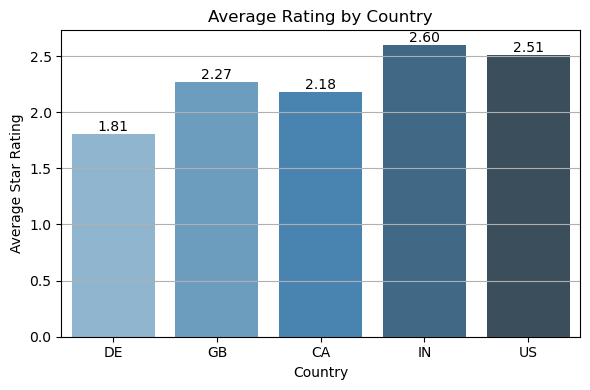

In [47]:
plt.figure(figsize=(6, 4))

colors = sns.color_palette("Blues_d", n_colors=len(country_stats))

ax = sns.barplot(
    data=country_stats,
    x='country',
    y='avg_score',
    palette=colors
)

plt.title("Average Rating by Country")
plt.xlabel("Country")
plt.ylabel("Average Star Rating")

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom', fontsize=10, color='black'
    )

plt.tight_layout()
plt.show()

Insight 1: Germany shows the highest level of dissatisfaction  
	•	Both the average star rating and sentiment score for Germany are significantly lower than all other countries.  
	•	This suggests that German users may be experiencing more issues or expressing stronger frustration with the app during this period.  
Insight 2: India and the United States are the most satisfied  
	•	India and the U.S. have the highest average ratings and the most positive sentiment scores among all regions.  
	•	This indicates that users in these countries generally have a more favorable experience with the app.   
Insight 3: There is a mismatch between ratings and sentiment in some countries  
	•	Canada (CA): The average rating is relatively low, but the sentiment score is close to neutral.  
	•	United Kingdom (GB): The average rating is moderate, yet the sentiment score is slightly negative.   

**Step 7 — Text cleaning for word clouds**

In [43]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)        # remove URLs
    text = re.sub(r"[^a-zA-Z\s]", " ", text)   # keep letters only
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['clean_text'] = df['review_full'].apply(clean_text)

df[['review_full', 'clean_text']].head()

,review_full,clean_text
0,List of friends in weird order When I want to ...,list of friends in weird order when i want to ...
1,Great companion I have been using the app for ...,great companion i have been using the app for ...
2,#Instagram #Fehler #Verbesserung dringend nöti...,instagram fehler verbesserung dringend n tig i...
3,Hässliche Layout Die neue Schriftart ist so un...,h ssliche layout die neue schriftart ist so un...
4,Instagram absoluter Müll geworden sorry aber e...,instagram absoluter m ll geworden sorry aber e...


**Step 8 — Positive vs Negative word clouds**

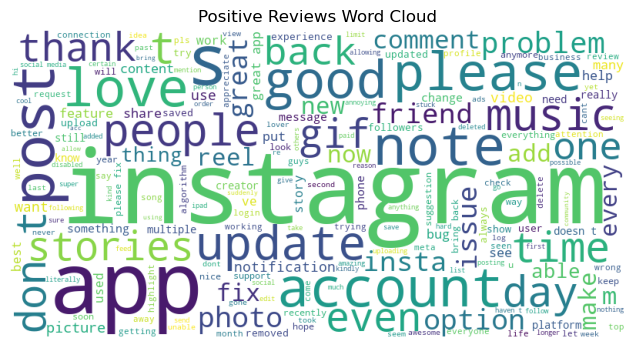

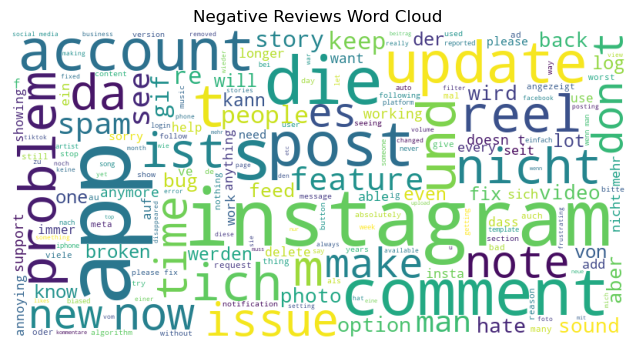

In [28]:
# Join all positive and negative reviews into two long strings
positive_text = " ".join(df[df['sentiment_label'] == 'positive']['clean_text'])
negative_text = " ".join(df[df['sentiment_label'] == 'negative']['clean_text'])

# Word cloud for positive reviews
wc_pos = WordCloud(
    width=800, height=400,
    background_color="white"
).generate(positive_text)

plt.figure(figsize=(8, 4))
plt.imshow(wc_pos)
plt.axis("off")
plt.title("Positive Reviews Word Cloud")
plt.show()

# Word cloud for negative reviews
wc_neg = WordCloud(
    width=800, height=400,
    background_color="white"
).generate(negative_text)

plt.figure(figsize=(8, 4))
plt.imshow(wc_neg)
plt.axis("off")
plt.title("Negative Reviews Word Cloud")
plt.show()

Positive reviews focus on core features like posting, stories, reels, and music, while negative reviews frequently mention bugs, account issues, updates, and problems with posting or notifications.